# RetinaFusionNet — Improved Training Pipeline (CIMT Classification)

## 1. Setup, Imports, Reproducibility

In [1]:
# !pip install timm albumentations torchmetrics opencv-python

In [2]:
# ============================================================
# Imports
# ============================================================
import os
import json
import copy
import random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    densenet121, DenseNet121_Weights,
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, auc,
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# ============================================================
# Reproducibility
# ============================================================
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
USE_AMP = torch.cuda.is_available()
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

Device: cpu | AMP: False


## 2. Configuration
Same dataset paths / split logic as the original notebooks - update `DATA_ROOT` and
`META_PATH` to match my machine if they differ.

In [3]:
# ============================================================
# Dataset Paths (same as my original notebooks — edit if needed)
# ============================================================
DATA_ROOT = Path(r"H:\AII\27907056\Fundus_CIMT_2903\Fundus_CIMT_2903 Dataset")
META_PATH = Path(r"H:\AII\27907056\data_info.json")
# ============================================================
# Backbones to train (in order) — used individually AND ensembled
# ============================================================
BACKBONES = ["efficientnet_b0", "resnet50", "densenet121"]
BACKBONE_FEATURES = {
    "efficientnet_b0": 1280,
    "resnet50": 2048,
    "densenet121": 1024,
}
IMG_SIZE = 224
EYE_MODE = "both" # "right" | "left" | "both"
USE_DEMOGRAPHICS = True
BATCH_SIZE = 32
EPOCHS = 30
WARMUP_EPOCHS = 2
EARLY_STOPPING_PATIENCE = 7
# ------------------------------------------------------------
# NEW: regularization / optimization hyperparameters
# ------------------------------------------------------------
BASE_LR_HEAD = 3e-4 # LR for the fusion head / classifier (new params)
BASE_LR_BACKBONE = 3e-5 # LR for the pretrained backbone (kept close to original)
WEIGHT_DECAY = 5e-4 # increased from 1e-4 in the original notebooks
DROPOUT = 0.30 # increased from 0.25 in the original notebooks
LABEL_SMOOTHING = 0.05 # new
GRAD_CLIP = 1.0
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = False
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULT_DIR = Path("results")
RESULT_DIR.mkdir(exist_ok=True)
N_BOOTSTRAPS = 2000
RANDOM_STATE = 42

## 3. Load Metadata & Official Train / Validation / Test Split

In [4]:
with open(META_PATH, "r") as f:
    metadata = json.load(f)
records = []
for patient_id, info in metadata.items():
    records.append({
        "patient_id": patient_id,
        "age": info["True_age"],
        "age_normalized": info["age"],
        "gender": info["gender"], # 0 = Female, 1 = Male
        "thickness": info["thickness"],
        "label": info["label"], # 0 = Normal, 1 = Thickened
        "group": info["group"], # 1 = Train, 2 = Val, 3 = Test
        "right_eye": info["right_eye"],
        "left_eye": info["left_eye"],
    })
df = pd.DataFrame(records)
print(f"Total Patients : {len(df):,}")
df.head()

Total Patients : 2,903


,patient_id,age,age_normalized,gender,thickness,label,group,right_eye,left_eye
0,2491006,63,0.684932,0,0.8,0,1,2491006_R.png,2491006_L.png
1,3730004,61,0.657534,1,1.2,1,1,3730004_R.png,3730004_L.png
2,3730006,64,0.698630,1,1.2,1,1,3730006_R.png,3730006_L.png
3,4738005,53,0.547945,0,0.7,0,1,4738005_R.png,4738005_L.png
4,6528003,66,0.726027,0,1.2,1,1,6528003_R.png,6528003_L.png


In [5]:
train_df = df[df.group == 1].reset_index(drop=True)
val_df = df[df.group == 2].reset_index(drop=True)
test_df = df[df.group == 3].reset_index(drop=True)
print("=" * 50)
print(f"Train : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test : {len(test_df)}")
print("=" * 50)
print("\nTrain label counts:")
print(train_df["label"].value_counts())

Train : 2603
Validation : 200
Test : 100

Train label counts:
label
1    1904
0     699
Name: count, dtype: int64


## 4. Dataset & Augmentation (Improved)
Same automated retina cropping as the original pipeline (kept identical - it's a
documented, validated part of the methodology). Augmentation is strengthened with
`CoarseDropout` (cutout - forces the model off any single localized region, including
crop-boundary artifacts) and a mild `GridDistortion` in addition to the existing
flip / rotate / brightness-contrast / affine transforms.

In [6]:
# ============================================================
# Config: auto-crop to retina, removing black background border
# (unchanged from original notebooks)
# ============================================================
CROP_TO_FUNDUS = True
CROP_TOL = 7
# ============================================================
# Improved Augmentations
# ============================================================
train_transform = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=12, border_mode=cv2.BORDER_CONSTANT, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), rotate=0, shear=0, p=0.30),
        # --- NEW: cutout-style regularization ---
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(0.05, 0.12),
            hole_width_range=(0.05, 0.12),
            fill=0,
            p=0.35,
        ),
        # --- NEW: mild non-rigid distortion (retina photos tolerate this well) ---
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=0.20),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ],
    additional_targets={"left": "image"}
)
valid_transform = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ],
    additional_targets={"left": "image"}
)
# Horizontally-flipped validation/test transform, used only for TTA at inference time
tta_flip_transform = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ],
    additional_targets={"left": "image"}
)

In [7]:
class FundusDataset(Dataset):
    """
    Unchanged from the original notebooks: automated retina cropping with a
    degenerate-crop fallback, synchronized left/right transforms, EYE_MODE handling.
    """
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    @staticmethod
    def crop_to_fundus(image, tol=CROP_TOL):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        mask = gray > tol
        if mask.sum() == 0:
            return image
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        cropped = image[y0:y1, x0:x1]
        if cropped.shape[0] < 10 or cropped.shape[1] < 10:
            return image
        return cropped
    @staticmethod
    def read_image(path):
        image = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found:\n{path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if CROP_TO_FUNDUS:
            image = FundusDataset.crop_to_fundus(image)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        return image
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        right_path = DATA_ROOT / row["right_eye"]
        left_path = DATA_ROOT / row["left_eye"]
        right = self.read_image(right_path)
        left = self.read_image(left_path)
        if self.transform:
            transformed = self.transform(image=right, left=left)
            right = transformed["image"]
            left = transformed["left"]
        else:
            right = torch.from_numpy(right).permute(2, 0, 1).float()
            left = torch.from_numpy(left).permute(2, 0, 1).float()
        if EYE_MODE == "right":
            images = torch.stack([right, right], dim=0)
        elif EYE_MODE == "left":
            images = torch.stack([left, left], dim=0)
        else:
            images = torch.stack([right, left], dim=0)
        demographic = torch.tensor(
            [row["age_normalized"], row["gender"]], dtype=torch.float32
        )
        label = torch.tensor(row["label"], dtype=torch.float32)
        return {
            "images": images,
            "demo": demographic,
            "label": label,
            "patient_id": row["patient_id"],
        }

In [8]:
train_dataset = FundusDataset(train_df, train_transform)
val_dataset = FundusDataset(val_df, valid_transform)
test_dataset = FundusDataset(test_df, valid_transform)
test_dataset_tta = FundusDataset(test_df, tta_flip_transform) # NEW: for TTA
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                           persistent_workers=PERSISTENT_WORKERS, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                         persistent_workers=PERSISTENT_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=PERSISTENT_WORKERS)
test_loader_tta = DataLoader(test_dataset_tta, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=PERSISTENT_WORKERS)
print(f"Training Samples : {len(train_dataset)}")
print(f"Validation Samples : {len(val_dataset)}")
print(f"Testing Samples : {len(test_dataset)}")

Training Samples : 2603
Validation Samples : 200
Testing Samples : 100


## 5. Model — No Gated Demographic Fusion

In [9]:
def build_backbone(model_name="efficientnet_b0", pretrained=True):
    if model_name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = efficientnet_b0(weights=weights)
        feature_dim = model.classifier[1].in_features
        model.classifier = nn.Identity()
        return model, feature_dim
    elif model_name == "resnet50":
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = resnet50(weights=weights)
        feature_dim = model.fc.in_features
        model.fc = nn.Identity()
        return model, feature_dim
    elif model_name == "densenet121":
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = densenet121(weights=weights)
        feature_dim = model.classifier.in_features
        model.classifier = nn.Identity()
        return model, feature_dim
    else:
        raise ValueError(f"Unsupported backbone: {model_name}")

class DualEyeFusionNetV2(nn.Module):
    """
    Same shared-weight dual-eye averaging as the original DualEyeFusionNet, plus:
      - configurable (higher) dropout
      - a learned gate over the demographic embedding before fusion
      - label-smoothing-compatible (returns raw logits; smoothing is applied in the loss)
    """
    def __init__(self, model_name, pretrained=True, freeze_backbone=False,
                 dropout=DROPOUT, use_demographics=USE_DEMOGRAPHICS):
        super().__init__()
        self.use_demographics = use_demographics
        self.backbone, feature_dim = build_backbone(model_name, pretrained)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.image_branch = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.demo_branch = nn.Sequential(
            nn.Linear(2, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(32, 64),
            nn.ReLU(inplace=True),
        )
        if self.use_demographics:
            # NEW: gate network — takes [image_feat, demo_feat] and outputs a
            # per-sample scalar in (0, 1) that scales the demographic branch
            self.demo_gate = nn.Sequential(
                nn.Linear(512 + 64, 64),
                nn.ReLU(inplace=True),
                nn.Linear(64, 1),
                nn.Sigmoid(),
            )
            self.classifier = nn.Sequential(
                nn.Linear(512 + 64, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, 1),
            )
        else:
            self.classifier = nn.Sequential(
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, 1),
            )

    def forward(self, images, demographic):
        right = images[:, 0]
        left = images[:, 1]
        right_feat = F.normalize(self.backbone(right), dim=1)
        left_feat = F.normalize(self.backbone(left), dim=1)
        image_feat = (right_feat + left_feat) / 2.0
        image_feat = self.image_branch(image_feat)
        if self.use_demographics:
            demo_feat = self.demo_branch(demographic)
            fusion = torch.cat([image_feat, demo_feat], dim=1)
        else:
            fusion = image_feat
        logits = self.classifier(fusion)
        return logits.squeeze(1)

## 6. Loss, Optimizer, LR Schedule
- **Label smoothing** is applied to the binary targets (`y -> y*(1-eps) + 0.5*eps`)
  before computing `BCEWithLogitsLoss`, which typically improves calibration and can
  give a small AUC/F1 bump on small datasets.
- **Discriminative learning rates**: the pretrained backbone gets a much lower LR
  (`BASE_LR_BACKBONE`) than the newly-initialized fusion head (`BASE_LR_HEAD`), since
  training everything at one uniform rate on ~2,600 patients is a large part of why the
  original runs overfit by epoch 5–6.
- **Linear warmup -> cosine annealing**, rather than cosine annealing from the first
  step, to avoid destabilizing the pretrained backbone early in training.

In [10]:
class LabelSmoothingBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None, smoothing=LABEL_SMOOTHING):
        super().__init__()
        self.smoothing = smoothing
        self.pos_weight = pos_weight
    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight
        )

def build_optimizer_and_scheduler(model, epochs=EPOCHS, warmup_epochs=WARMUP_EPOCHS,
                                   steps_per_epoch=1):
    backbone_params = list(model.backbone.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith("backbone.")]
    optimizer = AdamW(
        [
            {"params": backbone_params, "lr": BASE_LR_BACKBONE},
            {"params": head_params, "lr": BASE_LR_HEAD},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    total_steps = epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
    return optimizer, scheduler

## 7. Metrics, Threshold Tuning, Train / Validate Loops

In [11]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.uint8)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        metrics["auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["auc"] = np.nan
    return metrics

def find_best_threshold(y_true, y_prob, metric="f1"):
    """NEW: scan thresholds on the validation set and pick the one maximizing `metric`."""
    thresholds = np.linspace(0.05, 0.95, 181)
    best_thr, best_score = 0.5, -1.0
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.uint8)
        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "youden":
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            sens = tp / (tp + fn + 1e-9)
            spec = tn / (tn + fp + 1e-9)
            score = sens + spec - 1
        else:
            raise ValueError(metric)
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score

def bootstrap_auc_ci(y_true, y_prob, n_boot=N_BOOTSTRAPS, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    running_loss = 0.0
    y_true, y_prob = [], []
    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["images"].to(device, non_blocking=True)
        demo = batch["demo"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(images, demo)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step() # step-wise LR schedule (warmup + cosine)
        running_loss += loss.item() * labels.size(0)
        probs = torch.sigmoid(logits)
        y_true.extend(labels.detach().cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(np.array(y_true), np.array(y_prob))
    return epoch_loss, metrics

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    y_true, y_prob = [], []
    for batch in tqdm(loader, desc="Validation", leave=False):
        images = batch["images"].to(device, non_blocking=True)
        demo = batch["demo"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(images, demo)
            loss = criterion(logits, labels)
        running_loss += loss.item() * labels.size(0)
        probs = torch.sigmoid(logits)
        y_true.extend(labels.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(np.array(y_true), np.array(y_prob), threshold=threshold)
    return epoch_loss, metrics, np.array(y_true), np.array(y_prob)

@torch.no_grad()
def predict_probs(model, loader, device):
    """Plain forward pass returning (y_true, y_prob) — used for TTA averaging."""
    model.eval()
    y_true, y_prob = [], []
    for batch in loader:
        images = batch["images"].to(device)
        demo = batch["demo"].to(device)
        labels = batch["label"].to(device)
        with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(images, demo)
        probs = torch.sigmoid(logits)
        y_true.extend(labels.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_prob)

## 8. Training Loop (generalized over backbone)
Trains one backbone end-to-end with early stopping on validation ROC-AUC (best
checkpoint retained, as in the original notebooks), using the new loss/optimizer/schedule.

In [13]:
def train_backbone(model_name, epochs=EPOCHS, patience=EARLY_STOPPING_PATIENCE):
    print("=" * 70)
    print(f"Training backbone: {model_name}")
    print("=" * 70)
    model = DualEyeFusionNetV2(model_name=model_name, pretrained=True,
                                freeze_backbone=False, dropout=DROPOUT,
                                use_demographics=USE_DEMOGRAPHICS).to(DEVICE)
    num_pos = (train_df["label"] == 1).sum()
    num_neg = (train_df["label"] == 0).sum()
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)
    criterion = LabelSmoothingBCEWithLogitsLoss(pos_weight=pos_weight, smoothing=LABEL_SMOOTHING)
    optimizer, scheduler = build_optimizer_and_scheduler(
        model, epochs=epochs, warmup_epochs=WARMUP_EPOCHS, steps_per_epoch=len(train_loader)
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_acc": [], "val_acc": []}
    best_auc, best_epoch, patience_counter = -1.0, 0, 0
    best_model_wts = copy.deepcopy(model.state_dict())
    checkpoint_path = CHECKPOINT_DIR / f"no_gate_best_{model_name}.pth"
    print(f"{'Epoch':<7}{'Train Loss':<12}{'Val Loss':<12}{'Train AUC':<12}"
          f"{'Val AUC':<12}{'Train Acc':<12}{'Val Acc':<12}")
    for epoch in range(epochs):
        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, scaler, DEVICE
        )
        val_loss, val_metrics, _, _ = validate_one_epoch(model, val_loader, criterion, DEVICE)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_metrics["auc"])
        history["val_auc"].append(val_metrics["auc"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        print(f"{epoch+1:<7}{train_loss:<12.4f}{val_loss:<12.4f}"
              f"{train_metrics['auc']:<12.4f}{val_metrics['auc']:<12.4f}"
              f"{train_metrics['accuracy']:<12.4f}{val_metrics['accuracy']:<12.4f}")
        if val_metrics["auc"] > best_auc:
            best_auc, best_epoch = val_metrics["auc"], epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), checkpoint_path)
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            print("\nEarly stopping triggered.")
            break
    print(f"Best Validation AUC : {best_auc:.4f} (epoch {best_epoch})")
    model.load_state_dict(best_model_wts)
    return model, history, checkpoint_path

In [14]:
# ============================================================
# Train all three backbones
# ============================================================
trained_models = {}
histories = {}
for backbone_name in BACKBONES:
    model, history, ckpt_path = train_backbone(backbone_name)
    trained_models[backbone_name] = model
    histories[backbone_name] = history

Training backbone: efficientnet_b0
Epoch  Train Loss  Val Loss    Train AUC   Val AUC     Train Acc   Val Acc     


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

1      0.3508      0.3810      0.6811      0.8323      0.5679      0.7500      


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

11     0.1782      0.4258      0.9676      0.8201      0.8989      0.7500      


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

12     0.1644      0.5795      0.9761      0.8089      0.9267      0.7000      

Early stopping triggered.
Best Validation AUC : 0.8631 (epoch 5)


## 9. Per-Backbone Test Evaluation (with TTA + Threshold Tuning)
For each backbone: get validation probabilities to pick the F1-optimal threshold, then
evaluate on the test set both with TTA (average of original + horizontally-flipped
prediction) and report metrics at both the default 0.5 threshold and the tuned
threshold, plus the bootstrap 95% CI for ROC-AUC (threshold choice doesn't affect AUC
itself, only accuracy/precision/recall/F1).

In [15]:
def evaluate_backbone_with_tta(model, model_name):
    num_pos = (train_df["label"] == 1).sum()
    num_neg = (train_df["label"] == 0).sum()
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)
    criterion = LabelSmoothingBCEWithLogitsLoss(pos_weight=pos_weight, smoothing=LABEL_SMOOTHING)
    # 1) Tune threshold on validation set (no TTA needed here, just consistency)
    _, _, val_true, val_prob = validate_one_epoch(model, val_loader, criterion, DEVICE)
    best_thr, _ = find_best_threshold(val_true, val_prob, metric="f1")
    # 2) TTA on test set: average plain + horizontally-flipped probabilities
    y_true, prob_plain = predict_probs(model, test_loader, DEVICE)
    _, prob_flip = predict_probs(model, test_loader_tta, DEVICE)
    prob_tta = (prob_plain + prob_flip) / 2.0
    metrics_default = compute_metrics(y_true, prob_tta, threshold=0.5)
    metrics_tuned = compute_metrics(y_true, prob_tta, threshold=best_thr)
    mean_auc, lo, hi = bootstrap_auc_ci(y_true, prob_tta)
    print("=" * 60)
    print(f"{model_name} — TEST RESULTS (with TTA)")
    print("=" * 60)
    print(f"Tuned threshold (from val) : {best_thr:.3f}")
    print(f"Accuracy @0.50 / @tuned : {metrics_default['accuracy']:.4f} / {metrics_tuned['accuracy']:.4f}")
    print(f"Precision @0.50 / @tuned : {metrics_default['precision']:.4f} / {metrics_tuned['precision']:.4f}")
    print(f"Recall @0.50 / @tuned : {metrics_default['recall']:.4f} / {metrics_tuned['recall']:.4f}")
    print(f"F1 @0.50 / @tuned : {metrics_default['f1']:.4f} / {metrics_tuned['f1']:.4f}")
    print(f"ROC-AUC (bootstrap mean, 95% CI): {mean_auc:.4f} [{lo:.4f}, {hi:.4f}]")
    return {
        "model_name": model_name,
        "y_true": y_true,
        "prob_tta": prob_tta,
        "best_threshold": best_thr,
        "metrics_default": metrics_default,
        "metrics_tuned": metrics_tuned,
        "auc_mean": mean_auc, "auc_ci_lo": lo, "auc_ci_hi": hi,
    }

per_backbone_results = {}
for backbone_name, model in trained_models.items():
    per_backbone_results[backbone_name] = evaluate_backbone_with_tta(model, backbone_name)

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

efficientnet_b0 — TEST RESULTS (with TTA)
Tuned threshold (from val) : 0.525
Accuracy @0.50 / @tuned : 0.8700 / 0.8700
Precision @0.50 / @tuned : 0.8364 / 0.8776
Recall @0.50 / @tuned : 0.9200 / 0.8600
F1 @0.50 / @tuned : 0.8762 / 0.8687
ROC-AUC (bootstrap mean, 95% CI): 0.9242 [0.8674, 0.9694]


Validation:   0%|          | 0/7 [00:00<?, ?it/s]

resnet50 — TEST RESULTS (with TTA)
Tuned threshold (from val) : 0.490
Accuracy @0.50 / @tuned : 0.8400 / 0.8400
Precision @0.50 / @tuned : 0.8036 / 0.8036
Recall @0.50 / @tuned : 0.9000 / 0.9000
F1 @0.50 / @tuned : 0.8491 / 0.8491
ROC-AUC (bootstrap mean, 95% CI): 0.9411 [0.8951, 0.9772]


Validation:   0%|          | 0/7 [00:00<?, ?it/s]

densenet121 — TEST RESULTS (with TTA)
Tuned threshold (from val) : 0.570
Accuracy @0.50 / @tuned : 0.8200 / 0.7900
Precision @0.50 / @tuned : 0.7963 / 0.7843
Recall @0.50 / @tuned : 0.8600 / 0.8000
F1 @0.50 / @tuned : 0.8269 / 0.7921
ROC-AUC (bootstrap mean, 95% CI): 0.8838 [0.8164, 0.9422]


## 10. Cross-Backbone Ensemble
Average the TTA-processed probabilities from all trained backbones. Since the three
models were trained independently with different inductive biases (compound-scaled,
residual, densely-connected), their errors are only partially correlated - this is
usually the single highest-ROI step here since I already have all three checkpoints.

In [16]:
all_backbones_present = all(r["y_true"].shape == per_backbone_results[BACKBONES[0]]["y_true"].shape
                             for r in per_backbone_results.values())
assert all_backbones_present, "Test set ordering differs between backbones — check test_loader shuffling (should be False)."
y_true_ensemble = per_backbone_results[BACKBONES[0]]["y_true"]
ensemble_prob = np.mean([per_backbone_results[b]["prob_tta"] for b in BACKBONES], axis=0)
# Tune threshold for the ensemble on the validation set of EACH backbone,
# then average the tuned thresholds as a simple, transparent choice
# (alternative: re-run find_best_threshold directly against an ensembled

ensemble_val_probs = []
num_pos = (train_df["label"] == 1).sum()
num_neg = (train_df["label"] == 0).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)
criterion = LabelSmoothingBCEWithLogitsLoss(pos_weight=pos_weight, smoothing=LABEL_SMOOTHING)
for backbone_name, model in trained_models.items():
    _, _, val_true, val_prob = validate_one_epoch(model, val_loader, criterion, DEVICE)
    ensemble_val_probs.append(val_prob)
ensemble_val_prob_mean = np.mean(ensemble_val_probs, axis=0)
ensemble_best_thr, _ = find_best_threshold(val_true, ensemble_val_prob_mean, metric="f1")
metrics_default = compute_metrics(y_true_ensemble, ensemble_prob, threshold=0.5)
metrics_tuned = compute_metrics(y_true_ensemble, ensemble_prob, threshold=ensemble_best_thr)
mean_auc, lo, hi = bootstrap_auc_ci(y_true_ensemble, ensemble_prob)
print("=" * 60)
print("ENSEMBLE (EfficientNet-B0 + ResNet50 + DenseNet121, all with TTA)")
print("=" * 60)
print(f"Tuned threshold (from val) : {ensemble_best_thr:.3f}")
print(f"Accuracy @0.50 / @tuned : {metrics_default['accuracy']:.4f} / {metrics_tuned['accuracy']:.4f}")
print(f"Precision @0.50 / @tuned : {metrics_default['precision']:.4f} / {metrics_tuned['precision']:.4f}")
print(f"Recall @0.50 / @tuned : {metrics_default['recall']:.4f} / {metrics_tuned['recall']:.4f}")
print(f"F1 @0.50 / @tuned : {metrics_default['f1']:.4f} / {metrics_tuned['f1']:.4f}")
print(f"ROC-AUC (bootstrap mean, 95% CI): {mean_auc:.4f} [{lo:.4f}, {hi:.4f}]")
ensemble_results = {
    "model_name": "ensemble_3backbone_tta",
    "metrics_default": metrics_default,
    "metrics_tuned": metrics_tuned,
    "auc_mean": mean_auc, "auc_ci_lo": lo, "auc_ci_hi": hi,
    "threshold": ensemble_best_thr,
}

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

ENSEMBLE (EfficientNet-B0 + ResNet50 + DenseNet121, all with TTA)
Tuned threshold (from val) : 0.485
Accuracy @0.50 / @tuned : 0.8400 / 0.8400
Precision @0.50 / @tuned : 0.8036 / 0.8036
Recall @0.50 / @tuned : 0.9000 / 0.9000
F1 @0.50 / @tuned : 0.8491 / 0.8491
ROC-AUC (bootstrap mean, 95% CI): 0.9308 [0.8804, 0.9716]


## 11. Final Comparison Table & Plots

In [17]:
rows = []
for backbone_name in BACKBONES:
    r = per_backbone_results[backbone_name]
    rows.append({
        "Model": backbone_name,
        "Accuracy@0.5": r["metrics_default"]["accuracy"],
        "Accuracy@tuned": r["metrics_tuned"]["accuracy"],
        "Precision@tuned": r["metrics_tuned"]["precision"],
        "Recall@tuned": r["metrics_tuned"]["recall"],
        "F1@tuned": r["metrics_tuned"]["f1"],
        "ROC-AUC (mean)": r["auc_mean"],
        "CI Low": r["auc_ci_lo"],
        "CI High": r["auc_ci_hi"],
        "Tuned Threshold": r["best_threshold"],
    })
rows.append({
    "Model": "ENSEMBLE (3-backbone, TTA)",
    "Accuracy@0.5": ensemble_results["metrics_default"]["accuracy"],
    "Accuracy@tuned": ensemble_results["metrics_tuned"]["accuracy"],
    "Precision@tuned": ensemble_results["metrics_tuned"]["precision"],
    "Recall@tuned": ensemble_results["metrics_tuned"]["recall"],
    "F1@tuned": ensemble_results["metrics_tuned"]["f1"],
    "ROC-AUC (mean)": ensemble_results["auc_mean"],
    "CI Low": ensemble_results["auc_ci_lo"],
    "CI High": ensemble_results["auc_ci_hi"],
    "Tuned Threshold": ensemble_results["threshold"],
})
final_results_df = pd.DataFrame(rows)
final_results_df.to_csv(RESULT_DIR / "no_gate_improved_pipeline_results.csv", index=False)
final_results_df

,Model,Accuracy@0.5,Accuracy@tuned,Precision@tuned,Recall@tuned,F1@tuned,ROC-AUC (mean),CI Low,CI High,Tuned Threshold
0,efficientnet_b0,0.87,0.87,0.877551,0.86,0.868687,0.924186,0.867375,0.969418,0.525
1,resnet50,0.84,0.84,0.803571,0.90,0.849057,0.941110,0.895145,0.977163,0.490
2,densenet121,0.82,0.79,0.784314,0.80,0.792079,0.883802,0.816394,0.942232,0.570
3,"ENSEMBLE (3-backbone, TTA)",0.84,0.84,0.803571,0.90,0.849057,0.930780,0.880352,0.971591,0.485


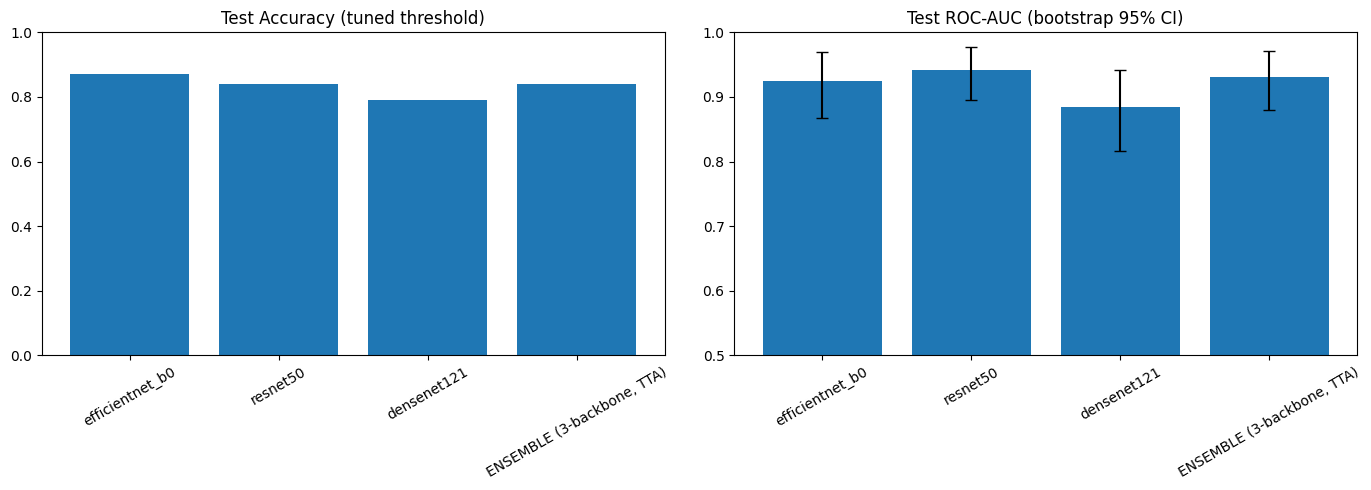

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = final_results_df["Model"]
axes[0].bar(labels, final_results_df["Accuracy@tuned"])
axes[0].set_title("Test Accuracy (tuned threshold)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(labels, final_results_df["ROC-AUC (mean)"])
axes[1].errorbar(
    labels,
    final_results_df["ROC-AUC (mean)"],
    yerr=[
        final_results_df["ROC-AUC (mean)"] - final_results_df["CI Low"],
        final_results_df["CI High"] - final_results_df["ROC-AUC (mean)"],
    ],
    fmt="none", ecolor="black", capsize=4,
)
axes[1].set_title("Test ROC-AUC (bootstrap 95% CI)")
axes[1].set_ylim(0.5, 1)
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(RESULT_DIR / "no_gate_improved_pipeline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

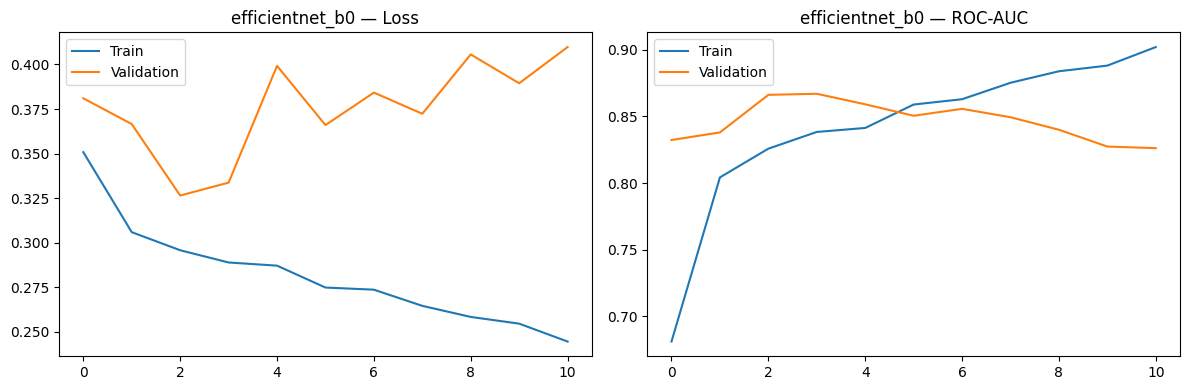

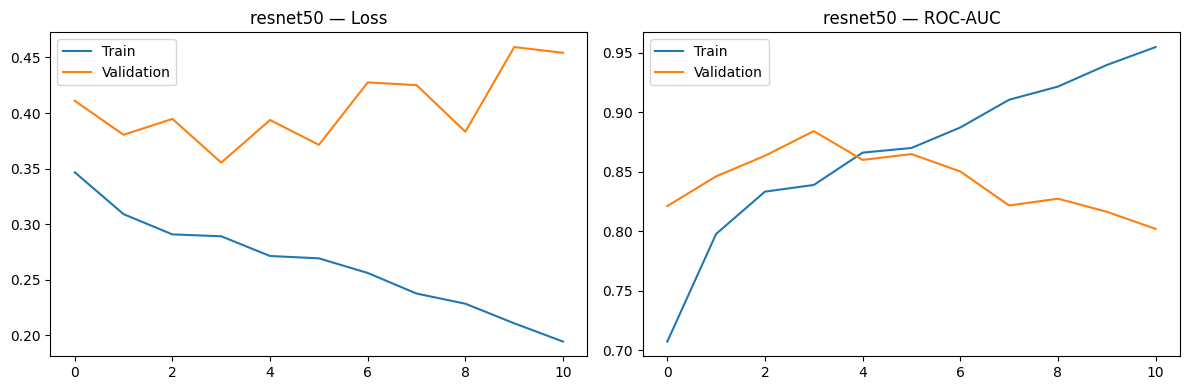

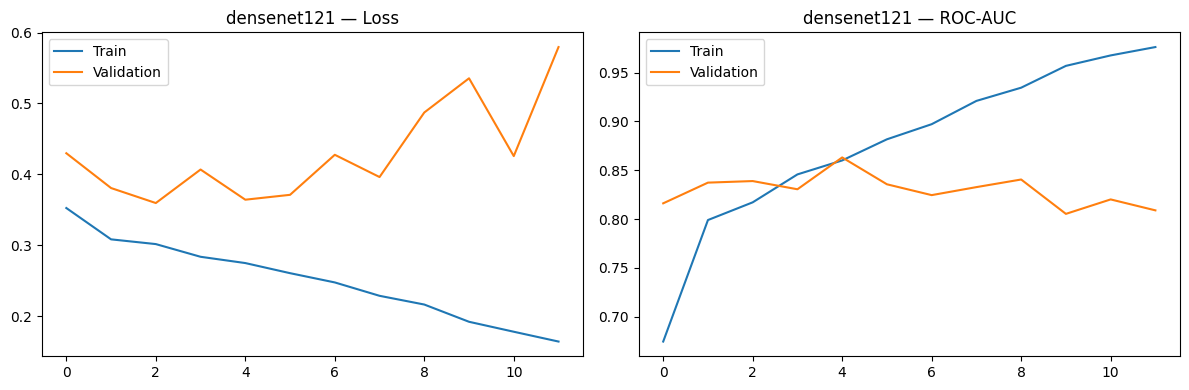

In [19]:
for backbone_name in BACKBONES:
    h = histories[backbone_name]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["train_loss"], label="Train")
    ax[0].plot(h["val_loss"], label="Validation")
    ax[0].set_title(f"{backbone_name} — Loss")
    ax[0].legend()
    ax[1].plot(h["train_auc"], label="Train")
    ax[1].plot(h["val_auc"], label="Validation")
    ax[1].set_title(f"{backbone_name} — ROC-AUC")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

## 12. Save Predictions & Checkpoints Summary

In [20]:
for backbone_name in BACKBONES:
    r = per_backbone_results[backbone_name]
    pd.DataFrame({
        "patient_id": test_df["patient_id"],
        "true_label": r["y_true"],
        "prob_tta": r["prob_tta"],
        "pred_default_0.5": (r["prob_tta"] >= 0.5).astype(int),
        "pred_tuned_thr": (r["prob_tta"] >= r["best_threshold"]).astype(int),
    }).to_csv(RESULT_DIR / f"no_gate_test_predictions_{backbone_name}.csv", index=False)

pd.DataFrame({
    "patient_id": test_df["patient_id"],
    "true_label": y_true_ensemble,
    "prob_ensemble": ensemble_prob,
    "pred_default_0.5": (ensemble_prob >= 0.5).astype(int),
    "pred_tuned_thr": (ensemble_prob >= ensemble_results["threshold"]).astype(int),
}).to_csv(RESULT_DIR / "no_gate_test_predictions_ensemble.csv", index=False)

print("Saved per-backbone and ensemble predictions + final_results table to ./results/")
print("Saved best checkpoints per backbone to ./checkpoints/")

Saved per-backbone and ensemble predictions + final_results table to ./results/
Saved best checkpoints per backbone to ./checkpoints/
